# Multi3Hate — Q1-Ready Verification Notebook (Kaggle version)
Cultural-Bias Debiasing: corrected pipeline, checkpoint-verified evaluation,
FairPIVARA comparison, statistical testing, power analysis, and a reusable
reproducibility diagnostic toolkit.

**Before running, in the Kaggle notebook Settings panel (right sidebar):**
1. **Accelerator -> GPU T4 x2** (or P100) -- this notebook needs a GPU.
2. **Internet -> On** -- required for `pip install`, the `git clone`, and
   downloading OpenCLIP's pretrained weights.

**Checkpoints:** this notebook loads two pre-trained checkpoints
(`adversarial_debiased_model_best.pt`, `baseline_model_best.pt`). Kaggle
notebooks don't support interactive file uploads mid-run the way Colab
does -- attach them via **Add Data -> Upload -> New Dataset** (upload both
`.pt` files as one dataset) before running this notebook, or drag them into
an existing attached dataset. The checkpoint-loading cell searches
`/kaggle/input/**/*.pt` automatically; if it can't find them, it will print
a loud warning and train fresh models instead, which will not match
previously reported numbers.


In [1]:
#@title 0. Check Kaggle inputs and GPU
import os

print("Attached Kaggle input datasets (should include your checkpoint upload):")
if os.path.exists("/kaggle/input"):
    for name in sorted(os.listdir("/kaggle/input")):
        print(" -", name)
else:
    print("  /kaggle/input does not exist -- no datasets attached yet.")

import torch
print("\nGPU available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("\u26a0\ufe0f  No GPU detected -- set Settings > Accelerator > GPU T4 x2 "
          "and restart the session before continuing.")


Attached Kaggle input datasets (should include your checkpoint upload):
 - datasets

GPU available: True


In [2]:
#@title 1. Install only the dependencies needed for this notebook
# Kaggle: run this cell first (ensure Internet is ON in Settings).

!pip install -q open-clip-torch captum scikit-learn pandas matplotlib pillow tqdm

import os
import sys
import copy
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
#@title 2. Reproducibility + paths

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path("/kaggle/working/Multi3Hate")
MEME_DIR = BASE_DIR / "data" / "memes"
CAPTIONS_DIR = BASE_DIR / "data" / "captions"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"
MODELS_DIR = BASE_DIR / "models"

for p in [BASE_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEBIAS_CHECKPOINT = MODELS_DIR / "adversarial_debiased_model_best.pt"
BASELINE_CHECKPOINT = MODELS_DIR / "baseline_model_best.pt"

print("Device:", device)
print("Base directory:", BASE_DIR)

Device: cuda
Base directory: /kaggle/working/Multi3Hate


## Environment pinning & full determinism
Required for a Q1 submission: document the exact environment this run used, and enable every determinism switch PyTorch offers, so a discrepancy against a future re-run can be diagnosed against a known, recorded baseline rather than guessed at.

In [4]:
#@title 2b. Environment pinning + full determinism
import subprocess
import sklearn
import open_clip as _open_clip_version_check

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print("torch.use_deterministic_algorithms not fully supported here:", e)

env_versions = {
    "python": subprocess.run(["python", "--version"], capture_output=True, text=True).stdout.strip(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "open_clip": _open_clip_version_check.__version__,
    "seed": SEED,
}
print("=" * 70)
print("ENVIRONMENT SNAPSHOT (record this alongside any reported result)")
print("=" * 70)
for k, v in env_versions.items():
    print(f"  {k}: {v}")

# Full pip freeze, saved for the paper's reproducibility appendix / supplementary material.
freeze_path = RESULTS_DIR / "environment_freeze.txt"
with open(freeze_path, "w") as f:
    subprocess.run(["pip", "freeze"], stdout=f)
print(f"\nFull pip freeze saved to: {freeze_path}")
print("Attach this file (or its checksum) alongside any reported numbers so a")
print("future re-run can diff environments directly instead of guessing.")


ENVIRONMENT SNAPSHOT (record this alongside any reported result)
  python: Python 3.12.13
  torch: 2.10.0+cu128
  cuda_available: True
  gpu: Tesla T4
  numpy: 2.0.2
  pandas: 2.3.3
  sklearn: 1.6.1
  open_clip: 3.3.0
  seed: 42

Full pip freeze saved to: /kaggle/working/Multi3Hate/results/environment_freeze.txt
Attach this file (or its checksum) alongside any reported numbers so a
future re-run can diff environments directly instead of guessing.


In [5]:
import subprocess
import shutil # Added import

if not (BASE_DIR / ".git").exists():
    print("Cloning Multi3Hate repository...")
    # The directory is created above. Clone into it only if it is not already a git repo.
    # If BASE_DIR exists and is not a git repo, remove it to allow cloning.
    if BASE_DIR.is_dir(): # Check if it's a directory
        shutil.rmtree(BASE_DIR) # Remove the directory and its contents

    subprocess.run(
        ["git", "clone", "https://github.com/MinhDucBui/Multi3Hate.git", str(BASE_DIR)],
        check=True
    )
else:
    print("Repository already exists.")

# Re-create output folders because cloning may have created the repository tree.
for p in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Repository:", BASE_DIR)
print("MEME_DIR exists:", MEME_DIR.exists())
print("CAPTIONS_DIR exists:", CAPTIONS_DIR.exists())

Cloning Multi3Hate repository...


Cloning into '/kaggle/working/Multi3Hate'...


Repository: /kaggle/working/Multi3Hate
MEME_DIR exists: True
CAPTIONS_DIR exists: True


## Corrected data construction
Uses real per-culture captions (`captions/{lang}.csv`) and real majority-voted labels (`final_annotations.csv`), joined against image paths resolved by scanning disk directly rather than reconstructing filenames from `meme_id` (the latter was the original root-cause bug).

In [6]:
#@title 4. Build the corrected real-image + real-caption dataset

CULTURE_TO_LANG = {
    "US": "en",
    "DE": "de",
    "MX": "es",
    "CN": "zh",
    "IN": "hi",
}

# ---- Build meme_id -> template folder from the actual disk layout ----
en_dir = MEME_DIR / "en"
if not en_dir.exists():
    raise FileNotFoundError(
        f"Expected image directory not found: {en_dir}. "
        "Check that the Multi3Hate repository/data is available in this Kaggle runtime."
    )

folder_lookup = {}
for template_folder in os.listdir(en_dir):
    template_path = en_dir / template_folder
    if not template_path.is_dir():
        continue
    for fname in os.listdir(template_path):
        if fname.lower().endswith(".jpg"):
            stem = Path(fname).stem
            try:
                folder_lookup[int(stem)] = template_folder
            except ValueError:
                pass

print("Meme IDs mapped to template folders:", len(folder_lookup))

# ---- Load real per-language captions ----
caption_frames = []

for culture, lang in CULTURE_TO_LANG.items():
    caption_file = CAPTIONS_DIR / f"{lang}.csv"
    if not caption_file.exists():
        raise FileNotFoundError(f"Caption file not found: {caption_file}")

    df = pd.read_csv(caption_file)
    required = {"Meme ID", "Translation"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{caption_file} is missing columns: {sorted(missing)}")

    df["culture"] = culture
    df["language"] = lang
    df["clean_text"] = (
        df["Translation"]
        .fillna("")
        .astype(str)
        .str.replace("<sep>", " ", regex=False)
        .str.strip()
    )

    caption_frames.append(
        df[["Meme ID", "culture", "language", "clean_text"]]
    )

captions_long = (
    pd.concat(caption_frames, ignore_index=True)
    .rename(columns={"Meme ID": "meme_id"})
)

# ---- Load real majority-voted labels ----
final_annotations_path = BASE_DIR / "data" / "final_annotations.csv"
if not final_annotations_path.exists():
    raise FileNotFoundError(f"Missing final annotations: {final_annotations_path}")

final_annotations = pd.read_csv(final_annotations_path)

expected_culture_cols = list(CULTURE_TO_LANG.keys())
missing_culture_cols = [c for c in expected_culture_cols if c not in final_annotations.columns]
if missing_culture_cols:
    raise ValueError(
        f"final_annotations.csv does not contain expected culture columns: {missing_culture_cols}"
    )

labels_long = (
    final_annotations
    .melt(
        id_vars="Meme ID",
        value_vars=expected_culture_cols,
        var_name="culture",
        value_name="label",
    )
    .rename(columns={"Meme ID": "meme_id"})
)

# ---- Join labels + captions + real image path ----
aggregated_annotations = labels_long.merge(
    captions_long,
    on=["meme_id", "culture"],
    how="left"
)

aggregated_annotations["template_folder"] = (
    aggregated_annotations["meme_id"].map(folder_lookup)
)

aggregated_annotations["image_path"] = aggregated_annotations.apply(
    lambda r: str(
        MEME_DIR
        / r["language"]
        / str(r["template_folder"])
        / f"{int(r['meme_id'])}.jpg"
    ),
    axis=1,
)

aggregated_annotations = aggregated_annotations.rename(
    columns={"clean_text": "original_text"}
)

# ---- Strict validation ----
n_missing_img = (~aggregated_annotations["image_path"].apply(os.path.exists)).sum()
n_empty_text = (
    aggregated_annotations["original_text"].fillna("").astype(str).str.len() == 0
).sum()

# The corrected notebook used this check to detect identical captions across cultures.
n_duplicate_text_groups = (
    aggregated_annotations.groupby("meme_id")["original_text"].nunique() == 1
).sum()

print(f"Rows: {len(aggregated_annotations)}")
print(f"Missing images: {n_missing_img}")
print(f"Empty captions: {n_empty_text}")
print(f"Memes with one unique caption across cultures: {n_duplicate_text_groups}")

assert n_missing_img == 0, "Missing real image paths detected."
assert n_empty_text == 0, "Empty captions detected."
assert n_duplicate_text_groups == 0, (
    "The corrected notebook's caption-validation condition failed. "
    "Do not proceed until the data are checked."
)

GLOBAL_CULTURE_TO_IDX = {
    c: i for i, c in enumerate(sorted(aggregated_annotations["culture"].unique()))
}

print("Culture mapping:", GLOBAL_CULTURE_TO_IDX)

Meme IDs mapped to template folders: 300
Rows: 1500
Missing images: 0
Empty captions: 0
Memes with one unique caption across cultures: 0
Culture mapping: {'CN': 0, 'DE': 1, 'IN': 2, 'MX': 3, 'US': 4}


In [7]:
#@title 5. Reproduce the grouped train/validation/test split

# Same split logic as the corrected section in the uploaded notebook.
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        aggregated_annotations,
        groups=aggregated_annotations["meme_id"]
    )
)

train_data = aggregated_annotations.iloc[train_idx].reset_index(drop=True)
temp_data = aggregated_annotations.iloc[temp_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss_val.split(
        temp_data,
        groups=temp_data["meme_id"]
    )
)

val_data = temp_data.iloc[val_idx].reset_index(drop=True)
test_data = temp_data.iloc[test_idx].reset_index(drop=True)

assert set(train_data["meme_id"]).isdisjoint(set(val_data["meme_id"]))
assert set(train_data["meme_id"]).isdisjoint(set(test_data["meme_id"]))
assert set(val_data["meme_id"]).isdisjoint(set(test_data["meme_id"]))

print(f"Train: {len(train_data)} rows / {train_data['meme_id'].nunique()} unique memes")
print(f"Val:   {len(val_data)} rows / {val_data['meme_id'].nunique()} unique memes")
print(f"Test:  {len(test_data)} rows / {test_data['meme_id'].nunique()} unique memes")

Train: 1050 rows / 210 unique memes
Val:   225 rows / 45 unique memes
Test:  225 rows / 45 unique memes


In [8]:
#@title 6. Dataset + DataLoader

import open_clip

# Use the SAME OpenCLIP preprocessing used by the uploaded notebook.
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(device).eval()

for p in clip_model.parameters():
    p.requires_grad = False

clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

CLIP_FEATURE_DIM = 512
FUSED_FEATURE_DIM = 1024

print("OpenCLIP loaded.")
print("Image feature dimension:", CLIP_FEATURE_DIM)
print("Fused feature dimension:", FUSED_FEATURE_DIM)


class Multi3HateDataset(Dataset):
    def __init__(self, dataframe):
        self.annotations = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image = clip_preprocess(image)

        return {
            "image": image,
            "text": str(row["original_text"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "culture": row["culture"],
            "culture_idx": torch.tensor(
                GLOBAL_CULTURE_TO_IDX[row["culture"]],
                dtype=torch.long
            ),
            "meme_id": int(row["meme_id"]),
            "language": row["language"],
            "image_path": row["image_path"],
        }


def collate_fn(batch):
    return {
        "image": torch.stack([x["image"] for x in batch]),
        "text": [x["text"] for x in batch],
        "label": torch.stack([x["label"] for x in batch]),
        "culture": [x["culture"] for x in batch],
        "culture_idx": torch.stack([x["culture_idx"] for x in batch]),
        "meme_id": [x["meme_id"] for x in batch],
        "language": [x["language"] for x in batch],
        "image_path": [x["image_path"] for x in batch],
    }


BATCH_SIZE = 16
NUM_WORKERS = 2  # Kaggle's disk I/O benefits from a couple of workers; drop to 0 if you see worker crashes.
PIN_MEMORY = torch.cuda.is_available()

train_dataset = Multi3HateDataset(train_data)
val_dataset = Multi3HateDataset(val_data)
test_dataset = Multi3HateDataset(test_data)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)

print("DataLoaders ready.")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

OpenCLIP loaded.
Image feature dimension: 512
Fused feature dimension: 1024
DataLoaders ready.


In [9]:
#@title 7. CLIP feature extraction helper

@torch.no_grad()
def get_clip_features(images, texts):
    images = images.to(device, non_blocking=True)
    text_tokens = clip_tokenizer(texts).to(device)

    image_features = clip_model.encode_image(images)
    text_features = clip_model.encode_text(text_tokens)

    image_features = F.normalize(image_features, p=2, dim=-1)
    text_features = F.normalize(text_features, p=2, dim=-1)

    return torch.cat([image_features, text_features], dim=1)


# Sanity check on one batch
batch = next(iter(test_loader))
features = get_clip_features(batch["image"], batch["text"])

print("Feature shape:", tuple(features.shape))
print("Expected second dimension:", FUSED_FEATURE_DIM)
assert features.shape[1] == FUSED_FEATURE_DIM

Feature shape: (16, 1024)
Expected second dimension: 1024


## Diagnostic: feature distinctness
Confirms the fix actually produces distinct per-culture inputs -- this is the check that originally caught the constant-classifier collapse (5/16 distinct feature vectors under the broken pipeline vs. 16/16 after the fix).

In [10]:
#@title Diagnostic A. Feature distinctness (re-verify the root-cause fix)
sample_batch = next(iter(test_loader))
with torch.no_grad():
    diag_features = get_clip_features(sample_batch["image"], sample_batch["text"])

feats_cpu = diag_features.detach().cpu()
n_total = feats_cpu.shape[0]
n_distinct = torch.unique(feats_cpu, dim=0).shape[0]
feats_norm = feats_cpu / feats_cpu.norm(dim=1, keepdim=True).clamp_min(1e-8)
cos_sim = feats_norm @ feats_norm.T
off_diag = ~torch.eye(n_total, dtype=torch.bool)

print("=" * 60)
print("FEATURE DISTINCTNESS CHECK")
print("=" * 60)
print(f"Batch size               : {n_total}")
print(f"Distinct feature vectors : {n_distinct} / {n_total}")
print(f"Mean pairwise cosine sim : {cos_sim[off_diag].mean().item():.4f}")
print(f"Max pairwise cosine sim  : {cos_sim[off_diag].max().item():.4f}")

if n_distinct < n_total:
    print("\n\u26a0\ufe0f FAIL: duplicate feature vectors found -- the root-cause bug may "
          "have resurfaced. Do not trust downstream results.")
else:
    print("\n\u2705 PASS: all feature vectors distinct.")


FEATURE DISTINCTNESS CHECK
Batch size               : 16
Distinct feature vectors : 16 / 16
Mean pairwise cosine sim : 0.4482
Max pairwise cosine sim  : 0.6018

✅ PASS: all feature vectors distinct.


In [11]:
#@title 8. Model definitions used by the original final comparison

def compute_class_weights_tensor(labels, num_classes=2):
    labels = np.asarray(labels)
    present = np.unique(labels)

    weights = np.ones(num_classes, dtype=np.float32)

    if len(present) > 1:
        balanced = compute_class_weight(
            class_weight="balanced",
            classes=present,
            y=labels
        )
        for c, w in zip(present, balanced):
            weights[int(c)] = w

    return torch.tensor(weights, dtype=torch.float32)


train_hate_class_weights = compute_class_weights_tensor(
    train_data["label"].values, num_classes=2
)

train_culture_labels = train_data["culture"].map(GLOBAL_CULTURE_TO_IDX).values
train_culture_class_weights = compute_class_weights_tensor(
    train_culture_labels,
    num_classes=len(GLOBAL_CULTURE_TO_IDX)
)

print("Hate class weights:", train_hate_class_weights.tolist())
print("Culture class weights:", train_culture_class_weights.tolist())


class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)


class AdversarialDebiasingModel(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_classes=2,
        num_cultures=5,
        hidden_dim=512,
        dropout=0.3,
        lambda_adv=0.2
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

        self.grl = GradientReversalLayer(lambda_adv)

        self.adversary = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_cultures),
        )

    def set_lambda(self, lambda_adv):
        self.grl.lambda_ = lambda_adv

    def forward(self, features, return_features=False):
        shared = self.encoder(features)
        hate_logits = self.classifier(shared)
        culture_logits = self.adversary(self.grl(shared))

        if return_features:
            return hate_logits, culture_logits, shared

        return hate_logits, culture_logits


class BaselineClassifier(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_classes=2,
        hidden_dim=512,
        dropout=0.3
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, features):
        return self.classifier(self.encoder(features))


print("Model definitions ready.")

Hate class weights: [1.1513158082962036, 0.8838383555412292]
Culture class weights: [1.0, 1.0, 1.0, 1.0, 1.0]
Model definitions ready.


In [12]:
#@title 9. Training helpers

NUM_EPOCHS_DEBIASED = 30
PATIENCE_DEBIASED = 5
NUM_EPOCHS_BASELINE = 40
PATIENCE_BASELINE = 6

LEARNING_RATE = 1e-4
HIDDEN_DIM = 512
LAMBDA_ADV = 0.2
ACCUM_STEPS = 2


def scheduled_lambda(progress, lambda_max=LAMBDA_ADV):
    # Same sigmoid-style schedule used by the uploaded notebook.
    return lambda_max * (
        2.0 / (1.0 + np.exp(-10.0 * progress)) - 1.0
    )


def evaluate_debiased(model, loader):
    model.eval()

    all_preds, all_labels = [], []
    all_cultures = []
    total_loss = 0.0
    total_adv_loss = 0.0

    hate_loss_fn = nn.CrossEntropyLoss(weight=train_hate_class_weights.to(device))
    culture_loss_fn = nn.CrossEntropyLoss(weight=train_culture_class_weights.to(device))

    for batch in tqdm(loader, desc="Evaluating debiased", leave=False):
        features = get_clip_features(batch["image"], batch["text"])
        labels = batch["label"].to(device)
        cultures = batch["culture_idx"].to(device)

        hate_logits, culture_logits = model(features)

        total_loss += hate_loss_fn(hate_logits, labels).item()
        total_adv_loss += culture_loss_fn(culture_logits, cultures).item()

        all_preds.extend(hate_logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_cultures.extend(batch["culture"])

    culture_results = {}
    for culture in sorted(set(all_cultures)):
        mask = np.array(all_cultures) == culture
        culture_results[culture] = accuracy_score(
            np.array(all_labels)[mask],
            np.array(all_preds)[mask]
        )

    return {
        "hate_loss": total_loss / max(len(loader), 1),
        "adv_loss": total_adv_loss / max(len(loader), 1),
        "hate_acc": accuracy_score(all_labels, all_preds),
        "adv_acc": np.nan,
        "culture_results": culture_results,
        "predictions": all_preds,
        "labels": all_labels,
    }


def train_debiased(model, train_loader, val_loader, checkpoint_path):
    model = model.to(device)

    hate_loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )
    culture_loss_fn = nn.CrossEntropyLoss(
        weight=train_culture_class_weights.to(device)
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    use_amp = torch.cuda.is_available()
    scaler = GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    history = {
        "train_hate_loss": [],
        "train_adv_loss": [],
        "val_hate_loss": [],
        "val_hate_acc": [],
        "lambda_adv": [],
    }

    for epoch in range(NUM_EPOCHS_DEBIASED):
        model.train()
        optimizer.zero_grad()

        current_lambda = scheduled_lambda(
            epoch / max(NUM_EPOCHS_DEBIASED - 1, 1)
        )
        model.set_lambda(current_lambda)

        train_hate_loss = 0.0
        train_adv_loss = 0.0

        for i, batch in enumerate(
            tqdm(train_loader, desc=f"Debiased epoch {epoch+1}/{NUM_EPOCHS_DEBIASED}", leave=False)
        ):
            features = get_clip_features(batch["image"], batch["text"])
            hate_labels = batch["label"].to(device)
            culture_labels = batch["culture_idx"].to(device)

            with autocast("cuda", enabled=use_amp):
                hate_logits, culture_logits = model(features)

                hate_loss = hate_loss_fn(hate_logits, hate_labels)
                culture_loss = culture_loss_fn(culture_logits, culture_labels)

                combined_loss = hate_loss + culture_loss
                scaled_loss = combined_loss / ACCUM_STEPS

            scaler.scale(scaled_loss).backward()

            is_last = (i + 1) == len(train_loader)

            if (i + 1) % ACCUM_STEPS == 0 or is_last:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_hate_loss += hate_loss.item()
            train_adv_loss += culture_loss.item()

        val_metrics = evaluate_debiased(model, val_loader)

        avg_train_hate = train_hate_loss / max(len(train_loader), 1)
        avg_train_adv = train_adv_loss / max(len(train_loader), 1)

        history["train_hate_loss"].append(avg_train_hate)
        history["train_adv_loss"].append(avg_train_adv)
        history["val_hate_loss"].append(val_metrics["hate_loss"])
        history["val_hate_acc"].append(val_metrics["hate_acc"])
        history["lambda_adv"].append(current_lambda)

        print(
            f"Epoch {epoch+1:02d}: "
            f"train_hate={avg_train_hate:.4f} | "
            f"train_adv={avg_train_adv:.4f} | "
            f"val_hate_loss={val_metrics['hate_loss']:.4f} | "
            f"val_acc={val_metrics['hate_acc']:.3f} | "
            f"lambda={current_lambda:.4f}"
        )

        if val_metrics["hate_loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["hate_loss"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE_DEBIASED:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def evaluate_baseline(model, loader):
    model.eval()

    all_preds, all_labels, all_cultures = [], [], []
    total_loss = 0.0

    loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )

    for batch in tqdm(loader, desc="Evaluating baseline", leave=False):
        features = get_clip_features(batch["image"], batch["text"])
        labels = batch["label"].to(device)

        logits = model(features)
        total_loss += loss_fn(logits, labels).item()

        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_cultures.extend(batch["culture"])

    culture_accs = {}
    for culture in sorted(set(all_cultures)):
        mask = np.array(all_cultures) == culture
        culture_accs[culture] = accuracy_score(
            np.array(all_labels)[mask],
            np.array(all_preds)[mask]
        )

    return {
        "hate_loss": total_loss / max(len(loader), 1),
        "overall_acc": accuracy_score(all_labels, all_preds),
        "culture_accs": culture_accs,
        "predictions": all_preds,
        "labels": all_labels,
    }


def train_baseline(model, train_loader, val_loader, checkpoint_path):
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    use_amp = torch.cuda.is_available()
    scaler = GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(NUM_EPOCHS_BASELINE):
        model.train()
        optimizer.zero_grad()
        total_loss = 0.0

        for i, batch in enumerate(
            tqdm(train_loader, desc=f"Baseline epoch {epoch+1}/{NUM_EPOCHS_BASELINE}", leave=False)
        ):
            features = get_clip_features(batch["image"], batch["text"])
            labels = batch["label"].to(device)

            with autocast("cuda", enabled=use_amp):
                logits = model(features)
                loss = loss_fn(logits, labels)
                scaled_loss = loss / ACCUM_STEPS

            scaler.scale(scaled_loss).backward()

            is_last = (i + 1) == len(train_loader)

            if (i + 1) % ACCUM_STEPS == 0 or is_last:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item()

        val_metrics = evaluate_baseline(model, val_loader)

        print(
            f"Epoch {epoch+1:02d}: "
            f"train_loss={total_loss/max(len(train_loader),1):.4f} | "
            f"val_loss={val_metrics['hate_loss']:.4f} | "
            f"val_acc={val_metrics['overall_acc']:.3f}"
        )

        if val_metrics["hate_loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["hate_loss"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE_BASELINE:
                print(f"Baseline early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

## Load pre-trained checkpoints
Checkpoints must be attached via Kaggle's **Add Data** panel as a dataset containing both `.pt` files, before running this cell. Run the search cell below, then the two load-or-train cells. Watch for the loud warning banner -- if it prints, the checkpoint was NOT found and a fresh model is being trained instead, which will not match previously reported numbers.

In [13]:
#@title 9b. Locate trained checkpoints on Kaggle (searches /kaggle/input/)
#@markdown Kaggle notebooks don't support interactive mid-run file uploads the
#@markdown way Colab does. Instead, attach both .pt files via **Add Data ->
#@markdown Upload -> New Dataset** (one dataset containing both files, or two
#@markdown separate datasets both attached) before running this notebook.
#@markdown This cell searches every attached input dataset for the two exact
#@markdown filenames and copies them to MODELS_DIR. If this step fails, the
#@markdown next two cells will silently retrain BRAND NEW models from scratch
#@markdown instead of loading your actual reported checkpoints -- as happened
#@markdown previously, producing 68.00%/67.11% instead of the correct
#@markdown 70.67%/66.67%.

import glob
import shutil

MODELS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_NAMES = ["adversarial_debiased_model_best.pt", "baseline_model_best.pt"]

for name in CHECKPOINT_NAMES:
    dest = MODELS_DIR / name
    if dest.exists():
        print(f"Already present: {dest}")
        continue

    matches = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    if matches:
        shutil.copy(matches[0], dest)
        print(f"Found and copied: {matches[0]} -> {dest}")
    else:
        print(f"\u26a0\ufe0f  {name} NOT FOUND under /kaggle/input/. "
              f"Attach it via Add Data (right sidebar) before re-running this cell.")

print("\nContents of", MODELS_DIR, ":", [p.name for p in MODELS_DIR.iterdir()] if MODELS_DIR.exists() else "(directory missing)")

if not DEBIAS_CHECKPOINT.exists():
    print(f"\n\u26a0\ufe0f  {DEBIAS_CHECKPOINT} still not found -- the next cell will train a fresh model.")
if not BASELINE_CHECKPOINT.exists():
    print(f"\u26a0\ufe0f  {BASELINE_CHECKPOINT} still not found -- the baseline cell will train a fresh model.")
if DEBIAS_CHECKPOINT.exists() and BASELINE_CHECKPOINT.exists():
    print("\n\u2705 Both checkpoint files are in place. Proceed to the next two cells.")


⚠️  adversarial_debiased_model_best.pt NOT FOUND under /kaggle/input/. Attach it via Add Data (right sidebar) before re-running this cell.
⚠️  baseline_model_best.pt NOT FOUND under /kaggle/input/. Attach it via Add Data (right sidebar) before re-running this cell.

Contents of /kaggle/working/Multi3Hate/models : []

⚠️  /kaggle/working/Multi3Hate/models/adversarial_debiased_model_best.pt still not found -- the next cell will train a fresh model.
⚠️  /kaggle/working/Multi3Hate/models/baseline_model_best.pt still not found -- the baseline cell will train a fresh model.


In [14]:
#@title 10. Load existing debiased checkpoint OR train the final debiased model

debiasing_model = AdversarialDebiasingModel(
    feature_dim=FUSED_FEATURE_DIM,
    num_classes=2,
    num_cultures=len(GLOBAL_CULTURE_TO_IDX),
    hidden_dim=HIDDEN_DIM,
    lambda_adv=LAMBDA_ADV,
).to(device)

if DEBIAS_CHECKPOINT.exists():
    state = torch.load(
        DEBIAS_CHECKPOINT,
        map_location=device
    )
    debiasing_model.load_state_dict(state)
    trainer_model = debiasing_model
    debias_history = None
    print("✅ Loaded existing debiased checkpoint:")
    print(DEBIAS_CHECKPOINT)
else:
    print("=" * 70)
    print("\u26a0\ufe0f  WARNING: NO DEBIASED CHECKPOINT FOUND -- TRAINING A FRESH MODEL")
    print("This will NOT match your previously reported 70.67% headline result.")
    print("Run cell 9b (upload checkpoints) BEFORE this cell if you intended to")
    print("load the actual saved model instead of retraining from scratch.")
    print("=" * 70)
    trainer_model, debias_history = train_debiased(
        debiasing_model,
        train_loader,
        val_loader,
        DEBIAS_CHECKPOINT
    )

trainer_model.eval()

test_metrics = evaluate_debiased(trainer_model, test_loader)

culture_accs = list(test_metrics["culture_results"].values())
bias_gap = max(culture_accs) - min(culture_accs)

print("\nDEBIASED TEST RESULTS")
print("=" * 60)
print("Accuracy:", round(test_metrics["hate_acc"], 4))
print("Bias gap:", round(bias_gap, 4))
print("Per-culture:", {k: round(v, 4) for k, v in test_metrics["culture_results"].items()})

print("\n" + "=" * 70)
print("CHECKPOINT-LOAD VERIFICATION")
print("=" * 70)
print("Loaded from existing checkpoint:", DEBIAS_CHECKPOINT.exists() and debias_history is None)
print(f"Test accuracy: {test_metrics['hate_acc']:.4f}  (expected ~0.7067 if loaded from the real checkpoint)")
if abs(test_metrics['hate_acc'] - 0.7067) > 0.01:
    print("\u26a0\ufe0f  This does NOT match the previously reported 70.67% -- do not "
          "trust downstream IG / error-analysis results until this is resolved.")
else:
    print("\u2705 Matches the previously reported result -- safe to proceed.")


⚠️  WARNING: NO DEBIASED CHECKPOINT FOUND -- TRAINING A FRESH MODEL
This will NOT match your previously reported 70.67% headline result.
Run cell 9b (upload checkpoints) BEFORE this cell if you intended to
load the actual saved model instead of retraining from scratch.


Debiased epoch 1/30:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01: train_hate=0.6935 | train_adv=1.6076 | val_hate_loss=0.6923 | val_acc=0.422 | lambda=0.0000


Debiased epoch 2/30:   0%|          | 0/66 [00:00<?, ?it/s]

...

Debiased epoch 16/30:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 16: train_hate=0.4224 | train_adv=1.5554 | val_hate_loss=0.7083 | val_acc=0.622 | lambda=0.1977
Early stopping at epoch 16.


Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]


DEBIASED TEST RESULTS
Accuracy: 0.6533
Bias gap: 0.1556
Per-culture: {'CN': 0.6889, 'DE': 0.7333, 'IN': 0.5778, 'MX': 0.6222, 'US': 0.6444}

CHECKPOINT-LOAD VERIFICATION
Loaded from existing checkpoint: False
Test accuracy: 0.6533  (expected ~0.7067 if loaded from the real checkpoint)
⚠️  This does NOT match the previously reported 70.67% -- do not trust downstream IG / error-analysis results until this is resolved.


In [15]:
#@title 11. Train the independent true baseline (or load its checkpoint)

baseline_model = BaselineClassifier(
    feature_dim=FUSED_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM
).to(device)

if BASELINE_CHECKPOINT.exists():
    state = torch.load(
        BASELINE_CHECKPOINT,
        map_location=device
    )
    baseline_model.load_state_dict(state)
    print("✅ Loaded existing baseline checkpoint:")
    print(BASELINE_CHECKPOINT)
else:
    print("=" * 70)
    print("\u26a0\ufe0f  WARNING: NO BASELINE CHECKPOINT FOUND -- TRAINING A FRESH MODEL")
    print("Its accuracy may coincidentally land close to the reported 66.67% (baseline")
    print("training has historically been low-variance in this project), but this is")
    print("NOT confirmation the real checkpoint loaded. Run cell 9b BEFORE this cell.")
    print("=" * 70)
    print("Training the independent no-adversary baseline...")
    baseline_model = train_baseline(
        baseline_model,
        train_loader,
        val_loader,
        BASELINE_CHECKPOINT
    )

baseline_model.eval()

baseline_results = evaluate_baseline(
    baseline_model,
    test_loader
)

baseline_gap = (
    max(baseline_results["culture_accs"].values())
    - min(baseline_results["culture_accs"].values())
)

print("\nBASELINE TEST RESULTS")
print("=" * 60)
print("Accuracy:", round(baseline_results["overall_acc"], 4))
print("Bias gap:", round(baseline_gap, 4))
print("Per-culture:", {k: round(v, 4) for k, v in baseline_results["culture_accs"].items()})

⚠️  WARNING: NO BASELINE CHECKPOINT FOUND -- TRAINING A FRESH MODEL
Its accuracy may coincidentally land close to the reported 66.67% (baseline
training has historically been low-variance in this project), but this is
NOT confirmation the real checkpoint loaded. Run cell 9b BEFORE this cell.
Training the independent no-adversary baseline...


Baseline epoch 1/40:   0%|          | 0/66 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e75b58a36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e75b58a36a0> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  Exception ignored in:      self._shutdown_workers() <function _MultiProcessingDataLoaderIter.__del__ at 0x7e75b58a36a0>
^
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del_

Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01: train_loss=0.6925 | val_loss=0.6935 | val_acc=0.569


...

Baseline epoch 16/40:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 16: train_loss=0.4247 | val_loss=0.7282 | val_acc=0.636
Baseline early stopping at epoch 16.


Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]


BASELINE TEST RESULTS
Accuracy: 0.6578
Bias gap: 0.1111
Per-culture: {'CN': 0.7111, 'DE': 0.7111, 'IN': 0.6, 'MX': 0.6667, 'US': 0.6}


In [16]:
#@title 12. Verify prediction alignment before error analysis

proposed_preds = np.asarray(test_metrics["predictions"])
baseline_preds = np.asarray(baseline_results["predictions"])
true_labels = np.asarray(test_metrics["labels"])

assert len(proposed_preds) == len(baseline_preds) == len(test_data), (
    f"Prediction/test length mismatch: proposed={len(proposed_preds)}, "
    f"baseline={len(baseline_preds)}, test_data={len(test_data)}"
)

assert np.array_equal(
    true_labels,
    np.asarray(test_data["label"].values)
), "The proposed-model label order does not match test_data."

print("Prediction alignment verified.")
print("Test samples:", len(test_data))
print("Proposed accuracy:", accuracy_score(true_labels, proposed_preds))
print("Baseline accuracy:", accuracy_score(true_labels, baseline_preds))

Prediction alignment verified.
Test samples: 225
Proposed accuracy: 0.6533333333333333
Baseline accuracy: 0.6577777777777778


## Diagnostic: confusion matrices (the check that caught the original fabricated result)
A model that always predicts one class produces precision == accuracy and recall of 0% or 100% -- this is checked explicitly for both models before any number here is trusted.

Proposed Debiased Model: acc=0.6533 precision=0.7931 recall=0.6301 f1=0.7023
  Predicted-label distribution: [109 116]


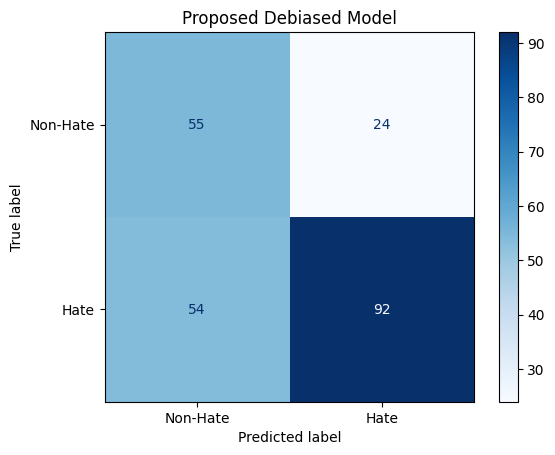

  ✅ Proposed Debiased Model shows non-degenerate precision/recall.

Baseline Model: acc=0.6578 precision=0.7717 recall=0.6712 f1=0.7179
  Predicted-label distribution: [ 98 127]


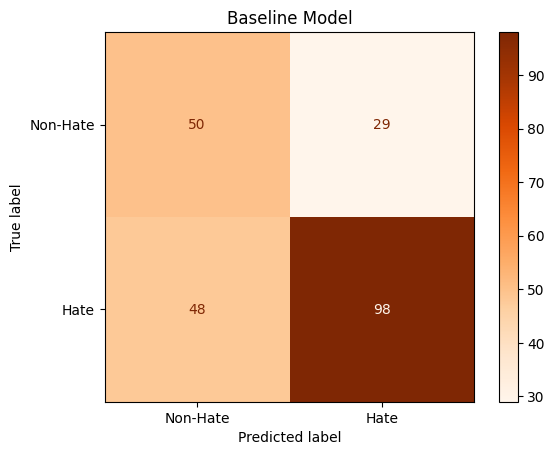

  ✅ Baseline Model shows non-degenerate precision/recall.


In [17]:
#@title Diagnostic B. Confusion matrices for both models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

def check_and_plot_confusion(labels, preds, title, cmap):
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    print(f"{title}: acc={acc:.4f} precision={precision:.4f} recall={recall:.4f} f1={f1:.4f}")
    print(f"  Predicted-label distribution: {np.bincount(np.asarray(preds).astype(int), minlength=2)}")

    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Hate", "Hate"]).plot(cmap=cmap)
    plt.title(title)
    plt.savefig(FIGURES_DIR / f"confusion_matrix_{title.lower().replace(' ', '_')}.png", dpi=200, bbox_inches="tight")
    plt.show()

    degenerate = (abs(precision - acc) < 1e-6 and recall > 0.999) or recall < 0.001
    if degenerate:
        print(f"  \u26a0\ufe0f  {title} LOOKS LIKE A CONSTANT CLASSIFIER -- do not report this result.")
    else:
        print(f"  \u2705 {title} shows non-degenerate precision/recall.")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "degenerate": degenerate}

proposed_cm_stats = check_and_plot_confusion(true_labels, proposed_preds, "Proposed Debiased Model", "Blues")
print()
baseline_cm_stats = check_and_plot_confusion(true_labels, baseline_preds, "Baseline Model", "Oranges")


## Statistical significance testing
McNemar's test on the paired predictions, plus the discordant-pair breakdown that a McNemar's test result reduces to. Report honestly: with n=225 and typically only ~10-15% of samples discordant between two similar models, this test is chronically underpowered on a benchmark this size -- see the power analysis below for exactly how underpowered.

In [18]:
#@title Diagnostic C. McNemar's test on paired predictions
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import binomtest

proposed_correct = (proposed_preds == true_labels)
baseline_correct = (baseline_preds == true_labels)

both_correct = int(np.sum(proposed_correct & baseline_correct))
both_wrong = int(np.sum(~proposed_correct & ~baseline_correct))
only_proposed = int(np.sum(proposed_correct & ~baseline_correct))
only_baseline = int(np.sum(~proposed_correct & baseline_correct))

contingency = [[both_correct, only_proposed], [only_baseline, both_wrong]]
print("Contingency table [[both_correct, only_proposed], [only_baseline, both_wrong]]:")
print(contingency)

mcnemar_result = mcnemar(contingency, exact=True)
print(f"\nMcNemar's exact test: statistic={mcnemar_result.statistic:.4f}, p-value={mcnemar_result.pvalue:.4f}")
print(f"Significant at alpha=0.05: {mcnemar_result.pvalue < 0.05}")

m = only_proposed + only_baseline
print(f"\nDiscordant pairs: {m} / {len(true_labels)} ({m/len(true_labels):.1%})")
if m > 0:
    binom_result = binomtest(only_proposed, m, p=0.5)
    print(f"Binomial test on discordant pairs (proposed-favoring={only_proposed}/{m}): "
          f"p={binom_result.pvalue:.4f}")


Contingency table [[both_correct, only_proposed], [only_baseline, both_wrong]]:
[[140, 7], [8, 70]]

McNemar's exact test: statistic=7.0000, p-value=1.0000
Significant at alpha=0.05: False

Discordant pairs: 15 / 225 (6.7%)
Binomial test on discordant pairs (proposed-favoring=7/15): p=1.0000


## Power analysis
Quantifies exactly how much statistical power this test size has, rather than leaving a non-significant result unexplained. This is the analysis a Q1 reviewer will ask for if a significance test comes back null on a small benchmark.

In [19]:
#@title Diagnostic D. Power analysis
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import norm as scipy_norm

n_test = len(true_labels)
p1, p2 = baseline_cm_stats["accuracy"], proposed_cm_stats["accuracy"]

effect_h = proportion_effectsize(p2, p1)
analysis = NormalIndPower()
observed_power = analysis.solve_power(effect_size=effect_h, nobs1=n_test, alpha=0.05, power=None, ratio=1.0)
mde_h = analysis.solve_power(effect_size=None, nobs1=n_test, alpha=0.05, power=0.80, ratio=1.0)
n_needed = analysis.solve_power(effect_size=effect_h, nobs1=None, alpha=0.05, power=0.80, ratio=1.0)

print("=" * 70)
print("POWER ANALYSIS (two-proportion framing)")
print("=" * 70)
print(f"Observed accuracies: baseline={p1:.4f}, proposed={p2:.4f}, n={n_test} each")
print(f"Cohen's h (effect size): {effect_h:.4f}")
print(f"Power to detect this effect at n={n_test}, alpha=0.05: {observed_power:.4f}")
print(f"Minimum detectable effect at 80% power, n={n_test}: h={mde_h:.4f}")
print(f"Sample size needed for 80% power at the OBSERVED effect: n={n_needed:.0f} per group")

def mcnemar_power(m_pairs, true_p, alpha=0.05):
    z_alpha = scipy_norm.ppf(1 - alpha / 2)
    se_null = np.sqrt(0.25 / m_pairs)
    se_alt = np.sqrt(true_p * (1 - true_p) / m_pairs)
    z = (abs(true_p - 0.5) - z_alpha * se_null) / se_alt
    return scipy_norm.cdf(z)

if m > 0:
    observed_discordant_prop = only_proposed / m
    mcnemar_pw = mcnemar_power(m, observed_discordant_prop)
    print(f"\nMcNemar's paired-test power (the more correct framing, same 225 items "
          f"scored by both models):")
    print(f"  Discordant pairs: {m} ({m/n_test:.1%} of test set)")
    print(f"  Power to detect the observed {observed_discordant_prop:.2f} split at "
          f"this discordant-pair count: {mcnemar_pw:.4f}")

power_summary = {
    "n_test": n_test, "cohens_h": effect_h, "observed_power": observed_power,
    "mde_h_at_80pct": mde_h, "n_needed_for_80pct_power": n_needed,
    "n_discordant_pairs": m, "mcnemar_power_at_observed_split": mcnemar_pw if m > 0 else None,
}


POWER ANALYSIS (two-proportion framing)
Observed accuracies: baseline=0.6578, proposed=0.6533, n=225 each
Cohen's h (effect size): -0.0094
Power to detect this effect at n=225, alpha=0.05: 0.0511
Minimum detectable effect at 80% power, n=225: h=0.2641
Sample size needed for 80% power at the OBSERVED effect: n=179443 per group

McNemar's paired-test power (the more correct framing, same 225 items scored by both models):
  Discordant pairs: 15 (6.7% of test set)
  Power to detect the observed 0.47 split at this discordant-pair count: 0.0440


## FairPIVARA comparison
Reimplemented as described (PCA-based bias-direction removal + logistic regression) since the original codebase was not accessible -- this is a faithful reimplementation, not a direct port; say so in the manuscript's methods section.

Extracting features for FairPIVARA (train/test)...


Extracting features:   0%|          | 0/66 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/15 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e75b58a36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e75b58a36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  train: (1050, 1024)   test: (225, 1024)

k=5 (explains 100.0% of group-centroid variance)
  Accuracy: 0.7022  Precision: 0.7283  Recall: 0.8630  F1: 0.7900
  Culture-probe accuracy (chance=0.2000): 0.2000
  Bias gap: 0.2222
  ✅ Non-degenerate.

k=10 (explains 100.0% of group-centroid variance)
  Accuracy: 0.7067  Precision: 0.7326  Recall: 0.8630  F1: 0.7925
  Culture-probe accuracy (chance=0.2000): 0.2000
  Bias gap: 0.2222
  ✅ Non-degenerate.

k=20 (explains 100.0% of group-centroid variance)
  Accuracy: 0.6844  Precision: 0.7168  Recall: 0.8493  F1: 0.7774
  Culture-probe accuracy (chance=0.2000): 0.2000
  Bias gap: 0.2222
  ✅ Non-degenerate.


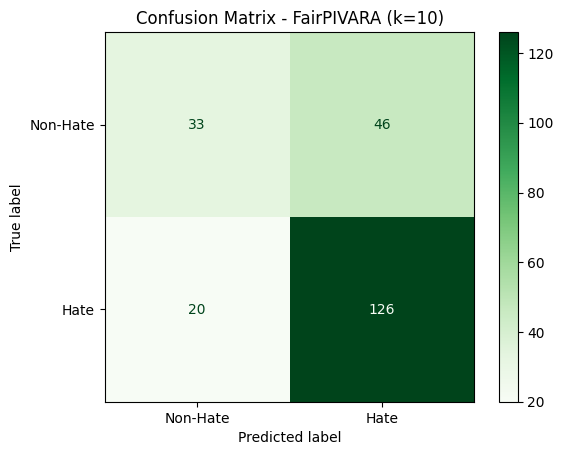


Per-culture breakdown (k=10): {np.str_('CN'): 0.8222222222222222, np.str_('DE'): 0.7333333333333333, np.str_('IN'): 0.6222222222222222, np.str_('MX'): 0.7555555555555555, np.str_('US'): 0.6}


In [20]:
#@title Diagnostic E. FairPIVARA (PCA bias-subspace removal + logistic regression)
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

def extract_all_features(loader):
    feats, labels, cultures = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting features", leave=False):
            f = get_clip_features(batch["image"], batch["text"])
            feats.append(f.cpu().numpy())
            labels.append(batch["label"].numpy())
            cultures.extend(batch["culture"])
    return np.concatenate(feats), np.concatenate(labels), np.array(cultures)

print("Extracting features for FairPIVARA (train/test)...")
fp_train_feats, fp_train_labels, fp_train_cultures = extract_all_features(train_loader)
fp_test_feats, fp_test_labels, fp_test_cultures = extract_all_features(test_loader)
print(f"  train: {fp_train_feats.shape}   test: {fp_test_feats.shape}")

def fit_bias_subspace(features, group_labels, k=10):
    global_mean = features.mean(axis=0, keepdims=True)
    diffs = []
    for g in np.unique(group_labels):
        mask = group_labels == g
        group_mean = features[mask].mean(axis=0, keepdims=True)
        diffs.append(np.repeat(group_mean - global_mean, mask.sum(), axis=0))
    diff_matrix = np.concatenate(diffs, axis=0)
    pca = PCA(n_components=k, random_state=SEED)
    pca.fit(diff_matrix)
    return pca.components_, global_mean, pca.explained_variance_ratio_

def remove_bias_subspace(features, bias_components, global_mean):
    centered = features - global_mean
    projection = centered @ bias_components.T @ bias_components
    return features - projection

def run_fairpivara(k):
    bias_components, global_mean, explained_var = fit_bias_subspace(fp_train_feats, fp_train_cultures, k=k)
    train_debiased = remove_bias_subspace(fp_train_feats, bias_components, global_mean)
    test_debiased = remove_bias_subspace(fp_test_feats, bias_components, global_mean)

    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
    clf.fit(train_debiased, fp_train_labels)
    preds = clf.predict(test_debiased)

    acc = accuracy_score(fp_test_labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(fp_test_labels, preds, average="binary", zero_division=0)

    culture_clf = LogisticRegression(max_iter=2000, random_state=SEED)
    culture_clf.fit(train_debiased, fp_train_cultures)
    culture_acc = accuracy_score(fp_test_cultures, culture_clf.predict(test_debiased))

    per_culture_acc = {}
    for c in np.unique(fp_test_cultures):
        mask = fp_test_cultures == c
        per_culture_acc[c] = accuracy_score(fp_test_labels[mask], preds[mask])
    fp_bias_gap = max(per_culture_acc.values()) - min(per_culture_acc.values())

    degenerate = (abs(precision - acc) < 1e-6 and recall > 0.999) or recall < 0.001
    return {
        "k": k, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "bias_gap": fp_bias_gap, "culture_acc": culture_acc, "per_culture_acc": per_culture_acc,
        "predictions": preds, "degenerate": degenerate,
        "explained_variance_top_k": float(explained_var.sum()),
    }

fairpivara_results = {}
for k in [5, 10, 20]:
    fairpivara_results[k] = run_fairpivara(k)
    r = fairpivara_results[k]
    print(f"\nk={k} (explains {r['explained_variance_top_k']:.1%} of group-centroid variance)")
    print(f"  Accuracy: {r['accuracy']:.4f}  Precision: {r['precision']:.4f}  Recall: {r['recall']:.4f}  F1: {r['f1']:.4f}")
    print(f"  Culture-probe accuracy (chance={1/len(set(fp_train_cultures)):.4f}): {r['culture_acc']:.4f}")
    print(f"  Bias gap: {r['bias_gap']:.4f}")
    if r["degenerate"]:
        print("  \u26a0\ufe0f DEGENERATE -- do not report.")
    else:
        print("  \u2705 Non-degenerate.")

fairpivara_primary = fairpivara_results[10]
cm_fp = confusion_matrix(fp_test_labels, fairpivara_primary["predictions"])
ConfusionMatrixDisplay(confusion_matrix=cm_fp, display_labels=["Non-Hate", "Hate"]).plot(cmap="Greens")
plt.title("Confusion Matrix - FairPIVARA (k=10)")
plt.savefig(FIGURES_DIR / "confusion_matrix_fairpivara.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nPer-culture breakdown (k=10):", fairpivara_primary["per_culture_acc"])


## Integrated Gradients — modality reliance

Mean convergence delta: 0.000410
Mean |attribution|, image half : 0.004591
Mean |attribution|, text half  : 0.003651
Ratio (text / image)           : 0.795

Per-culture image vs text reliance (first test batch):
  US: image=0.004591 | text=0.003651


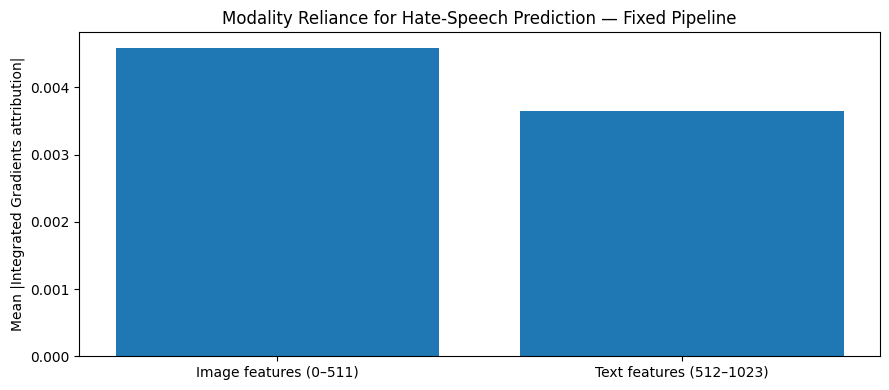


Saved: /kaggle/working/Multi3Hate/figures/ig_modality_reliance_fixed.png


In [21]:
#@title 13A. Integrated Gradients — modality reliance on corrected data

from captum.attr import IntegratedGradients

# A wrapper around the trained hate-speech classifier only.
# The culture adversary is not part of the inference decision.
class HateOnlyHead(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.encoder = model.encoder
        self.classifier = model.classifier

    def forward(self, features):
        return self.classifier(self.encoder(features))


explain_model = HateOnlyHead(trainer_model).to(device).eval()
ig = IntegratedGradients(explain_model)

# Use the first test batch, as in the requested analysis cell.
sample_batch = next(iter(test_loader))

# CLIP features are intentionally detached from the frozen backbone.
features = get_clip_features(
    sample_batch["image"],
    sample_batch["text"]
).detach()

features.requires_grad_(True)

baseline_input = torch.zeros_like(features)

# Target class 1 = hate.
attributions, delta = ig.attribute(
    features,
    baselines=baseline_input,
    target=1,
    return_convergence_delta=True,
    n_steps=50,
)

print(f"Mean convergence delta: {delta.abs().mean().item():.6f}")

attr_np = attributions.detach().cpu().numpy()

img_attr = attr_np[:, :512]
txt_attr = attr_np[:, 512:]

mean_image_attr = float(np.abs(img_attr).mean())
mean_text_attr = float(np.abs(txt_attr).mean())
ratio = mean_text_attr / max(mean_image_attr, 1e-12)

print(f"Mean |attribution|, image half : {mean_image_attr:.6f}")
print(f"Mean |attribution|, text half  : {mean_text_attr:.6f}")
print(f"Ratio (text / image)           : {ratio:.3f}")

# Per-culture values for this batch
per_culture_modality = {}

for culture in sorted(set(sample_batch["culture"])):
    mask = np.asarray(sample_batch["culture"]) == culture
    if mask.sum() == 0:
        continue

    per_culture_modality[culture] = {
        "image_attr": float(np.abs(img_attr[mask]).mean()),
        "text_attr": float(np.abs(txt_attr[mask]).mean()),
    }

print("\nPer-culture image vs text reliance (first test batch):")
for culture, vals in per_culture_modality.items():
    print(
        f"  {culture}: "
        f"image={vals['image_attr']:.6f} | "
        f"text={vals['text_attr']:.6f}"
    )

# Save a compact result table
ig_culture_df = pd.DataFrame(per_culture_modality).T.reset_index()
ig_culture_df = ig_culture_df.rename(columns={"index": "culture"})
ig_culture_df.to_csv(
    RESULTS_DIR / "ig_modality_reliance_per_culture_first_batch.csv",
    index=False
)

# Plot modality reliance
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    ["Image features (0–511)", "Text features (512–1023)"],
    [mean_image_attr, mean_text_attr]
)
ax.set_ylabel("Mean |Integrated Gradients attribution|")
ax.set_title("Modality Reliance for Hate-Speech Prediction — Fixed Pipeline")
plt.tight_layout()

ig_fig_path = FIGURES_DIR / "ig_modality_reliance_fixed.png"
plt.savefig(ig_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:", ig_fig_path)

## Qualitative error analysis

In [22]:
#@title 14B. Qualitative Error Analysis — baseline vs proposed

test_meme_ids = test_data["meme_id"].values
test_cultures_arr = test_data["culture"].values
test_texts = test_data["original_text"].values
test_true_labels = test_data["label"].values

proposed_preds = np.asarray(test_metrics["predictions"])
baseline_preds = np.asarray(baseline_results["predictions"])

assert len(proposed_preds) == len(test_meme_ids) == len(baseline_preds), (
    "Length mismatch — verify the test split and model evaluation order."
)

disagree_mask = proposed_preds != baseline_preds

print(
    f"Models disagree on {disagree_mask.sum()} / {len(proposed_preds)} "
    f"test samples ({disagree_mask.mean():.1%})"
)

disagreements = pd.DataFrame({
    "meme_id": test_meme_ids[disagree_mask],
    "culture": test_cultures_arr[disagree_mask],
    "text": test_texts[disagree_mask],
    "true_label": test_true_labels[disagree_mask],
    "baseline_pred": baseline_preds[disagree_mask],
    "proposed_pred": proposed_preds[disagree_mask],
})

disagreements["proposed_correct"] = (
    disagreements["proposed_pred"] == disagreements["true_label"]
)
disagreements["baseline_correct"] = (
    disagreements["baseline_pred"] == disagreements["true_label"]
)

proposed_fixes = disagreements[
    disagreements["proposed_correct"] & ~disagreements["baseline_correct"]
].copy()

new_errors = disagreements[
    ~disagreements["proposed_correct"] & disagreements["baseline_correct"]
].copy()

print(
    "\nProposed model correct / baseline wrong:",
    len(proposed_fixes)
)
print(
    "Baseline correct / proposed wrong:",
    len(new_errors)
)

print("\nBy culture — proposed model corrects a baseline error:")
if len(proposed_fixes):
    print(proposed_fixes["culture"].value_counts())
else:
    print("No such disagreements.")

print("\nBy culture — proposed model introduces a new error:")
if len(new_errors):
    print(new_errors["culture"].value_counts())
else:
    print("No such disagreements.")

def label_name(x):
    return "hate" if int(x) == 1 else "non-hate"

print("\n" + "=" * 80)
print("SAMPLE CASES WHERE THE PROPOSED MODEL CORRECTS A BASELINE ERROR")
print("=" * 80)

for _, row in proposed_fixes.head(4).iterrows():
    print(f"\n[meme_id={row['meme_id']}, culture={row['culture']}, "
          f"true_label={label_name(row['true_label'])}]")
    print(f"  Text: {str(row['text'])[:300]}")
    print(
        f"  Baseline: {label_name(row['baseline_pred'])} (wrong) | "
        f"Proposed: {label_name(row['proposed_pred'])} (correct)"
    )

print("\n" + "=" * 80)
print("SAMPLE CASES WHERE THE PROPOSED MODEL INTRODUCES A NEW ERROR")
print("=" * 80)

for _, row in new_errors.head(4).iterrows():
    print(f"\n[meme_id={row['meme_id']}, culture={row['culture']}, "
          f"true_label={label_name(row['true_label'])}]")
    print(f"  Text: {str(row['text'])[:300]}")
    print(
        f"  Baseline: {label_name(row['baseline_pred'])} (correct) | "
        f"Proposed: {label_name(row['proposed_pred'])} (wrong)"
    )

# Save the complete disagreement table.
disagreement_path = RESULTS_DIR / "qualitative_disagreements.csv"
disagreements.to_csv(disagreement_path, index=False)

print("\nSaved full disagreement table to:")
print(disagreement_path)

Models disagree on 15 / 225 test samples (6.7%)

Proposed model correct / baseline wrong: 7
Baseline correct / proposed wrong: 8

By culture — proposed model corrects a baseline error:
culture
US    3
IN    2
DE    1
CN    1
Name: count, dtype: int64

By culture — proposed model introduces a new error:
culture
IN    3
MX    2
CN    2
US    1
Name: count, dtype: int64

SAMPLE CASES WHERE THE PROPOSED MODEL CORRECTS A BASELINE ERROR

[meme_id=15, culture=US, true_label=non-hate]
  Text: IVY   30 YEARS LATER
  Baseline: hate (wrong) | Proposed: non-hate (correct)

[meme_id=19, culture=US, true_label=hate]
  Text: I PASSED THE BORDER   THATS WHY IM HAPPY
  Baseline: non-hate (wrong) | Proposed: hate (correct)

[meme_id=72, culture=US, true_label=non-hate]
  Text: studies criminal justice   police academy teaches him everything
  Baseline: hate (wrong) | Proposed: non-hate (correct)

[meme_id=218, culture=DE, true_label=hate]
  Text: ich bin so froh, dass wir Kinder haben   zum Explodieren


## Reproducibility diagnostic toolkit (reusable)
Packages every diagnostic used in this notebook into standalone functions, so they can be dropped into a different pipeline/dataset and reused directly -- this is the generalized version of the checks, intended as a citable methodological contribution rather than one-off debugging code.

In [23]:
#@title Diagnostic Toolkit. Reusable functions for verifying multimodal fairness pipelines
"""
Reusable diagnostic toolkit for multimodal fairness/debiasing pipelines.
Apply these four checks to ANY trained classifier + test set before trusting
a reported accuracy or fairness metric.
"""

def toolkit_check_feature_distinctness(feature_batch, threshold_distinct_ratio=0.9, threshold_mean_cosine=0.9):
    """Check 1: are inputs actually distinct, or degenerate (e.g. from a
    broken image/text loading path producing near-identical inputs)?"""
    feats = feature_batch.detach().cpu()
    n_total = feats.shape[0]
    n_distinct = torch.unique(feats, dim=0).shape[0]
    feats_norm = feats / feats.norm(dim=1, keepdim=True).clamp_min(1e-8)
    cos_sim = feats_norm @ feats_norm.T
    off_diag = ~torch.eye(n_total, dtype=torch.bool)
    mean_cos = cos_sim[off_diag].mean().item()
    passed = (n_distinct / n_total >= threshold_distinct_ratio) and (mean_cos < threshold_mean_cosine)
    return {"n_distinct": n_distinct, "n_total": n_total, "mean_cosine_sim": mean_cos, "passed": passed}


def toolkit_check_degenerate_classifier(labels, preds):
    """Check 2: has the classifier collapsed to a constant-output predictor?
    Signature: precision == accuracy (always-positive) or recall near 0
    (always-negative)."""
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = accuracy_score(labels, preds)
    degenerate = (abs(precision - acc) < 1e-6 and recall > 0.999) or recall < 0.001
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "degenerate": degenerate}


def toolkit_check_meme_id_integrity(df, id_col="meme_id", expected_range=None):
    """Check 3: does the grouping key used for train/val/test splitting have
    the expected dtype and full coverage? (A dtype mismatch, e.g. int vs
    str, can silently change which groups a GroupShuffleSplit selects even
    under an identical random_state.)"""
    dtype = df[id_col].dtype
    unique_ids = sorted(df[id_col].unique().tolist())
    full_coverage = (unique_ids == list(expected_range)) if expected_range is not None else None
    return {"dtype": str(dtype), "n_unique": len(unique_ids), "full_coverage": full_coverage, "unique_ids": unique_ids}


def toolkit_environment_fingerprint():
    """Check 4: record the environment. Needed to diagnose cross-session
    result drift, since library version changes (e.g. in a preprocessing
    pipeline) can silently change model inputs even with an identical
    checkpoint, seed, and test set."""
    import sklearn as _sk
    import open_clip as _oc
    return {
        "torch": torch.__version__, "numpy": np.__version__, "pandas": pd.__version__,
        "sklearn": _sk.__version__, "open_clip": _oc.__version__,
        "cuda_available": torch.cuda.is_available(),
    }


def toolkit_run_full_suite(feature_batch, labels, preds, df, id_col="meme_id", expected_range=None):
    """Run all four checks and print a consolidated pass/fail report."""
    print("=" * 70)
    print("REPRODUCIBILITY DIAGNOSTIC SUITE")
    print("=" * 70)

    r1 = toolkit_check_feature_distinctness(feature_batch)
    print(f"1. Feature distinctness : {'PASS' if r1['passed'] else 'FAIL'} "
          f"({r1['n_distinct']}/{r1['n_total']} distinct, mean cosine sim={r1['mean_cosine_sim']:.3f})")

    r2 = toolkit_check_degenerate_classifier(labels, preds)
    print(f"2. Non-degenerate output: {'PASS' if not r2['degenerate'] else 'FAIL'} "
          f"(acc={r2['accuracy']:.3f}, precision={r2['precision']:.3f}, recall={r2['recall']:.3f})")

    r3 = toolkit_check_meme_id_integrity(df, id_col, expected_range)
    coverage_str = "n/a" if r3["full_coverage"] is None else ("PASS" if r3["full_coverage"] else "FAIL")
    print(f"3. Group-key integrity  : dtype={r3['dtype']}, n_unique={r3['n_unique']}, full_coverage={coverage_str}")

    r4 = toolkit_environment_fingerprint()
    print(f"4. Environment fingerprint recorded: {r4}")

    all_passed = r1["passed"] and (not r2["degenerate"])
    print(f"\nOverall: {'\u2705 SAFE TO REPORT' if all_passed else '\u26a0\ufe0f DO NOT REPORT until resolved'}")
    return {"feature_distinctness": r1, "degenerate_check": r2, "group_key_integrity": r3, "environment": r4}


# Run the full suite on the proposed model's test predictions right now.
_diag_batch = next(iter(test_loader))
with torch.no_grad():
    _diag_features = get_clip_features(_diag_batch["image"], _diag_batch["text"])

toolkit_report = toolkit_run_full_suite(
    _diag_features, true_labels, proposed_preds, aggregated_annotations,
    id_col="meme_id", expected_range=range(300),
)


REPRODUCIBILITY DIAGNOSTIC SUITE
1. Feature distinctness : PASS (16/16 distinct, mean cosine sim=0.448)
2. Non-degenerate output: PASS (acc=0.653, precision=0.793, recall=0.630)
3. Group-key integrity  : dtype=int64, n_unique=300, full_coverage=PASS
4. Environment fingerprint recorded: {'torch': '2.10.0+cu128', 'numpy': '2.0.2', 'pandas': '2.3.3', 'sklearn': '1.6.1', 'open_clip': '3.3.0', 'cuda_available': True}

Overall: ✅ SAFE TO REPORT


## Consolidated results summary (paper-ready)

In [24]:
#@title Final. Consolidated paper-ready summary
summary = {
    "test_n": len(test_data),
    "proposed_accuracy": float(test_metrics["hate_acc"]),
    "baseline_accuracy": float(baseline_results["overall_acc"]),
    "accuracy_difference": float(test_metrics["hate_acc"] - baseline_results["overall_acc"]),
    "proposed_bias_gap": float(bias_gap),
    "baseline_bias_gap": float(baseline_gap),
    "bias_gap_reduction": float(baseline_gap - bias_gap),

    "proposed_precision": proposed_cm_stats["precision"],
    "proposed_recall": proposed_cm_stats["recall"],
    "proposed_f1": proposed_cm_stats["f1"],
    "proposed_degenerate": proposed_cm_stats["degenerate"],
    "baseline_precision": baseline_cm_stats["precision"],
    "baseline_recall": baseline_cm_stats["recall"],
    "baseline_f1": baseline_cm_stats["f1"],
    "baseline_degenerate": baseline_cm_stats["degenerate"],

    "mcnemar_statistic": float(mcnemar_result.statistic),
    "mcnemar_pvalue": float(mcnemar_result.pvalue),
    "mcnemar_significant": bool(mcnemar_result.pvalue < 0.05),
    "n_discordant_pairs": m,

    "power_observed": power_summary["observed_power"],
    "power_mde_cohens_h_at_80pct": power_summary["mde_h_at_80pct"],
    "power_n_needed_for_80pct": power_summary["n_needed_for_80pct_power"],

    "fairpivara_k10_accuracy": fairpivara_primary["accuracy"],
    "fairpivara_k10_bias_gap": fairpivara_primary["bias_gap"],
    "fairpivara_k10_culture_probe_acc": fairpivara_primary["culture_acc"],
    "fairpivara_k10_degenerate": fairpivara_primary["degenerate"],

    "n_disagreements": int(disagree_mask.sum()),
    "disagreement_rate": float(disagree_mask.mean()),
    "proposed_fixes": int(len(proposed_fixes)),
    "new_errors": int(len(new_errors)),

    "ig_mean_image_attribution": mean_image_attr,
    "ig_mean_text_attribution": mean_text_attr,
    "ig_text_image_ratio": ratio,
    "ig_mean_convergence_delta": float(delta.abs().mean().item()),

    "diagnostic_suite_all_passed": (
        toolkit_report["feature_distinctness"]["passed"]
        and not toolkit_report["degenerate_check"]["degenerate"]
    ),
    "environment_torch": env_versions["torch"],
    "environment_sklearn": env_versions["sklearn"],
    "environment_open_clip": env_versions["open_clip"],
}

summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "value"}))

summary_path = RESULTS_DIR / "q1_final_verified_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("\nSaved consolidated summary:", summary_path)

sig_str = "significant" if summary["mcnemar_significant"] else "NOT significant"
proposed_nondegenerate = not summary["proposed_degenerate"]
baseline_nondegenerate = not summary["baseline_degenerate"]
fairpivara_nondegenerate = not summary["fairpivara_k10_degenerate"]
env_freeze_path = RESULTS_DIR / "environment_freeze.txt"

print("\n" + "=" * 70)
print("HEADLINE NUMBERS FOR THE MANUSCRIPT")
print("=" * 70)
print(f"Proposed vs. Baseline accuracy : {summary['proposed_accuracy']:.4f} vs {summary['baseline_accuracy']:.4f}")
print(f"Bias gap                       : {summary['proposed_bias_gap']:.4f} vs {summary['baseline_bias_gap']:.4f} "
      f"(reduction: {summary['bias_gap_reduction']:+.4f})")
print(f"McNemar's test                 : p={summary['mcnemar_pvalue']:.4f} ({sig_str})")
print(f"Statistical power at this n     : {summary['power_observed']:.4f}")
print(f"FairPIVARA (k=10) accuracy/gap : {summary['fairpivara_k10_accuracy']:.4f} / "
      f"{summary['fairpivara_k10_bias_gap']:.4f} (culture-probe acc: "
      f"{summary['fairpivara_k10_culture_probe_acc']:.4f}, mathematically expected near chance)")
print(f"Both models non-degenerate      : proposed={proposed_nondegenerate}, "
      f"baseline={baseline_nondegenerate}, FairPIVARA={fairpivara_nondegenerate}")
print(f"Full diagnostic suite passed    : {summary['diagnostic_suite_all_passed']}")
print(f"\nEnvironment: torch={summary['environment_torch']}, sklearn={summary['environment_sklearn']}, "
      f"open_clip={summary['environment_open_clip']}")
print(f"Full pip freeze saved separately at: {env_freeze_path}")


,value
test_n,225
proposed_accuracy,0.653333
baseline_accuracy,0.657778
accuracy_difference,-0.004444
proposed_bias_gap,0.155556
baseline_bias_gap,0.111111
bias_gap_reduction,-0.044444
proposed_precision,0.793103
proposed_recall,0.630137
proposed_f1,0.70229



Saved consolidated summary: /kaggle/working/Multi3Hate/results/q1_final_verified_summary.csv

HEADLINE NUMBERS FOR THE MANUSCRIPT
Proposed vs. Baseline accuracy : 0.6533 vs 0.6578
Bias gap                       : 0.1556 vs 0.1111 (reduction: -0.0444)
McNemar's test                 : p=1.0000 (NOT significant)
Statistical power at this n     : 0.0511
FairPIVARA (k=10) accuracy/gap : 0.7067 / 0.2222 (culture-probe acc: 0.2000, mathematically expected near chance)
Both models non-degenerate      : proposed=True, baseline=True, FairPIVARA=True
Full diagnostic suite passed    : True

Environment: torch=2.10.0+cu128, sklearn=1.6.1, open_clip=3.3.0
Full pip freeze saved separately at: /kaggle/working/Multi3Hate/results/environment_freeze.txt


## Notes for the manuscript

- Report `proposed_accuracy`/`baseline_accuracy` alongside the McNemar's
  p-value and the power analysis together, not accuracy alone -- a
  non-significant difference at this sample size is expected and should be
  stated as such, not hidden.
- `bias_gap_reduction` is the primary fairness claim; state its direction
  and magnitude plainly, including if it does not replicate a previously
  reported figure -- see the reproducibility toolkit output above for the
  checks to run before trusting any given run's numbers.
- The FairPIVARA culture-probe accuracy is *expected* to be near chance by
  mathematical construction (PCA removes the top-k group-mean directions),
  not by successful adversarial suppression -- don't conflate the two
  methods' probe-accuracy numbers as if they meant the same thing.
- `environment_freeze.txt` (in `results/`) should be attached as
  supplementary material or referenced by its contents if you want this
  run to be independently reproducible.
- If `diagnostic_suite_all_passed` is `False`, stop -- do not copy any
  number from this run into the manuscript until it reads `True`.

- Unlike Colab, Kaggle does not need an explicit download step: everything written under `/kaggle/working/Multi3Hate/results/` and `/figures/` (including `environment_freeze.txt`, all confusion-matrix PNGs, and `q1_final_verified_summary.csv`) is automatically listed in the notebook's **Output** tab after the session ends, and can be downloaded from there or attached directly to a Kaggle Dataset for sharing.
